In [ ]:
# 1
!pip install category_encoders

     |████████████████████████████████| 81kB 3.6MB/s 


In [1]:
# 2
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

Mounted at /content/drive


In [3]:
def plot(pred):
  df = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
  pred = pd.DataFrame(pred)
  df = df[['displayId','clicked']]
  a = df.join(pred).rename(columns={0:'pred'}, inplace=False).groupby('displayId').mean()
  b = a.sort_values(by =['clicked'])
  b['ind'] = range(len(b))
  b.plot(x='ind', y=['pred'])
  b.plot(x='ind', y=['clicked'])


In [4]:
def reliability_diagram(probs):
  from sklearn.calibration import calibration_curve
  from matplotlib import pyplot
  import matplotlib.pyplot as plt

  df = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
  y = df['clicked']
  fop, mpv = calibration_curve(y, probs, n_bins=10, normalize=True)
  # plot perfectly calibrated
  plt.figure()
  pyplot.plot([0, 1], [0, 1], linestyle='--')
  # plot calibrated reliability
  pyplot.plot(mpv, fop, marker='.')
  pyplot.show()

In [5]:
def score(actual, predicted, prob):
  from sklearn.metrics import classification_report,confusion_matrix
  from sklearn.metrics import roc_auc_score
  from sklearn.metrics import log_loss
  print('CONFUSION MATRIX')
  print(confusion_matrix(actual, predicted, normalize='all'))
  print(classification_report(actual, predicted))
  print("AUC:")
  print(roc_auc_score(actual, predicted))
  print("CROSS-ENTROPY:")
  print(log_loss(actual, prob))

In [6]:
# 3
project_dir = '/content/drive/MyDrive/ML_Project/'
train = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
print(train.head())
print(len(train))
train = train.dropna()
print(len(train))
test = pd.read_csv("/content/drive/MyDrive/ML_Project/test_data.csv")
print(test.head())
print(len(test))
test = test.dropna()
print(len(test))

   displayId      timestamp  dayOfWeek  hourOfDay  advertiserId  campaignId  creativeId  publisher  widgetId  device  os  browser  source    docId   userId  clicked
0    4706262  1578429005696          4          0           290        7855           6         10      6262       0   0        0      11  3543873  2688642        1
1    4706262  1578429005696          4          0          1386        7967          15         10      6262       0   0        0      11  3543873  2688642        0
2    4706262  1578429005696          4          0           378        1160        3610         10      6262       0   0        0      11  3543873  2688642        0
3    4706267  1578429007726          4          0          6642         804        3475         14       607       1   3        0      15  6245475  2688641        1
4    4706267  1578429007726          4          0          8414        6155        5271         14       607       1   3        0      15  6245475  2688641        0
3768416
37

In [ ]:
# 4
y_train = train['clicked']
train = train.drop('clicked', 1)


'\nfrom collections import Counter, defaultdict\nfor col in test.columns:\n    l1 = Counter(list(train[col]))\n    l2 = Counter(list(test[col]))\n    print(col)\n    ours = 0\n    all = 0\n    ours_weighted = 0\n    all_weighted = 0\n    ours3 = 0\n    all3 = 0\n    for k2, v2 in l2.items():\n        ours += 1 if k2 in l1.keys() else 0\n        ours_weighted += v2 if k2 in l1.keys() else 0\n        all += 1\n        all_weighted += v2\n        ours3 += l1[k2] if k2 in l1.keys() else 0\n        all3 += l1[k2]\n\n    print(ours / all)\n    print(ours_weighted / all_weighted)\n    print((ours3) / (all3 + 0.0001))\n    print()\n'

In [ ]:
# 5
import math
print(train.describe())
print({a:str(len(train[a].unique())) for a in train.columns})
print(sum([math.log2(len(train[a].unique())) for a in train.columns if not a in ['timestamp', 'displayId', 'source', 'device']]))
print(len(train))

one_hots = ['dayOfWeek', 'hourOfDay', 'device', 'os', 'browser']
big_uniques = ['displayId', 'timestamp', 'docId', 'userId']
middle = list({'advertiserId': '200', 'campaignId': '474', 'creativeId': '2696', 
          'publisher': '759', 'widgetId': '1165', 'source': '2868'}.keys())
print([type(train[a][0]) for a in train.columns])

          displayId     timestamp     dayOfWeek     hourOfDay  advertiserId    campaignId    creativeId     publisher      widgetId        device            os       browser        source         docId        userId
count  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06
mean   3.044210e+06  1.579005e+12  2.822654e+00  1.128271e+01  4.851426e+03  4.556158e+03  3.923456e+03  2.463082e+02  7.500866e+03  3.409207e-01  4.306032e-01  1.209916e+00  1.848337e+03  5.065981e+06  1.501631e+06
std    1.019521e+06  3.571385e+08  1.914881e+00  5.618726e+00  2.899004e+03  2.647040e+03  2.482294e+03  5.164171e+02  4.301190e+03  4.817837e-01  6.516009e-01  2.629931e+00  6.529483e+03  3.424284e+06  7.132266e+05
min    1.115095e+06  1.578429e+12  0.000000e+00  0.000000e+00  1.000000e+00  3.000000e+01  6.000000e+00  0.000000e+00  9.000000e+00  0.0

In [ ]:
# 7
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from category_encoders import *
from datetime import datetime

train = train.drop('source', 1)
train = train.drop('displayId', 1)
train = train.drop('device', 1)
train = train.drop('docId', 1)
train = train.drop('userId', 1)
train = train.drop('timestamp', 1)

test = test.drop('source', 1)
test = test.drop('displayId', 1)
test = test.drop('device', 1)
test = test.drop('docId', 1)
test = test.drop('userId', 1)
test = test.drop('timestamp', 1)

old_cols = train.columns
encoder= BinaryEncoder(cols=train.columns,return_df=True)
train = encoder.fit_transform(train)
test = encoder.fit_transform(test)

# remove zeroes:
for col in old_cols:
    train = train.drop(str(col) + "_0", 1)
    test = test.drop(str(col) + "_0", 1)

for col in train.columns:
    if not col in test.columns:
        test[col] = 0

print(train.shape)
print(train.head(10))

print(test.shape)
print(test.head(10))

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm
/usr/local/lib/python3.6/dist-packages/category_encoders/utils.py:21: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  elif pd.api.types.is_categorical(cols):
/usr/local/lib/python3.6/dist-packages/category_encoders/utils.py:21: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  elif pd.api.types.is_categorical(cols):


(3768416, 68)
   dayOfWeek_1  dayOfWeek_2  dayOfWeek_3  hourOfDay_1  hourOfDay_2  hourOfDay_3  hourOfDay_4  hourOfDay_5  advertiserId_1  advertiserId_2  advertiserId_3  advertiserId_4  advertiserId_5  advertiserId_6  advertiserId_7  advertiserId_8  campaignId_1  campaignId_2  campaignId_3  campaignId_4  campaignId_5  campaignId_6  campaignId_7  campaignId_8  campaignId_9  creativeId_1  creativeId_2  creativeId_3  creativeId_4  creativeId_5  creativeId_6  creativeId_7  creativeId_8  creativeId_9  creativeId_10  creativeId_11  creativeId_12  publisher_1  publisher_2  publisher_3  publisher_4  publisher_5  publisher_6  publisher_7  publisher_8  publisher_9  publisher_10  widgetId_1  widgetId_2  widgetId_3  widgetId_4  widgetId_5  widgetId_6  widgetId_7  widgetId_8  widgetId_9  widgetId_10  widgetId_11  os_1  os_2  os_3  browser_1  browser_2  browser_3  browser_4  browser_5  browser_6  browser_7
0            0            0            1            0            0            0            0   

In [ ]:
# 8
train = train.reindex(sorted(train.columns), axis=1)
test = test.reindex(sorted(test.columns), axis=1)

print(train.head())
print(test.head())

   advertiserId_1  advertiserId_2  advertiserId_3  advertiserId_4  advertiserId_5  advertiserId_6  advertiserId_7  advertiserId_8  browser_1  browser_2  browser_3  browser_4  browser_5  browser_6  browser_7  campaignId_1  campaignId_2  campaignId_3  campaignId_4  campaignId_5  campaignId_6  campaignId_7  campaignId_8  campaignId_9  creativeId_1  creativeId_10  creativeId_11  creativeId_12  creativeId_2  creativeId_3  creativeId_4  creativeId_5  creativeId_6  creativeId_7  creativeId_8  creativeId_9  dayOfWeek_1  dayOfWeek_2  dayOfWeek_3  hourOfDay_1  hourOfDay_2  hourOfDay_3  hourOfDay_4  hourOfDay_5  os_1  os_2  os_3  publisher_1  publisher_10  publisher_2  publisher_3  publisher_4  publisher_5  publisher_6  publisher_7  publisher_8  publisher_9  widgetId_1  widgetId_10  widgetId_11  widgetId_2  widgetId_3  widgetId_4  widgetId_5  widgetId_6  widgetId_7  widgetId_8  widgetId_9
0               0               0               0               0               0               0            

In [ ]:
# 11
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


fs = SelectKBest(score_func=chi2, k=30)
fs.fit(train, y_train)
train = pd.DataFrame(fs.transform(train))
test = pd.DataFrame(fs.transform(test))

print(train.shape)
print(test.shape)

(3768416, 30)
(1072876, 30)


In [ ]:
#randomly removing false data to equlize the ratio of true and false
import numpy as np

false_index = y_train[y_train == 0].index
false_len = len(y_train[y_train == 0])
true_len = len(y_train) - false_len
f2t_rate = int(false_len / true_len)
remove_n = (f2t_rate-1)*true_len

drop_indices = np.random.choice(false_index, remove_n, replace=False)
y = y_train.drop(drop_indices)
X = train.drop(drop_indices).reset_index().drop('index', axis=1)

#MODELS




<div dir='rtl'>
<font size=5> 



این روش که بسیار مشابه Bagging است علاوه بر اینکه در هر مرحله به صورت تصادفی یک بخش از داده را انتخاب میکند، ویژگی‌های (feature) تصادفی نیز انتخاب می‌کند و از همه ویژگی‌های استفاده نمی‌کند. سپس روی هر بخش از دادگان انتخاب شده، یک درخت آموزش داده می‌شود، و در نهایت تجمیع میانگین این درخت‌ها مدل نهایی را می‌سازد. هرچند که این مدل در بسیاری از مسائل بسیار کاربرد دارد اما در مسائلی که داده‌ها نامتوازن هستند بسیار ضعیف عمل می‌کند. برای همین تغییراتی در مدل داده شده تا عملکرد آن بهبود پیدا کند.
یک روش استفاده از مدل وزن‌دار آن است. به این صورت که درخت‌هایی که تاثیر بیشتری در جداسازی دادگان اقلیت دارند وزن بیشتری می‌گیرند.
برای مدل‌هایی که آموزش دادیم وزندهی تمامی جنگل‌ها را به صورت ‘balanced_subsample’ در نظر گرفتیم یعنی در هر قسم از داده‌هایی که برای آموزش بر‌می‌دارد نسبت داده‌های کلاس ۰ و ۱ با یکدیگر یکی هستند. برای بهینه کردن پارامتر‌های دیگر نیز تنها به دو پارامتر max_depth و n_estimator بسنده کردیم که max_depth بیشینه عمقی است که هر یک از درخت‌ها می‌توانند داشته باشند و n_estimator تعداد دفعاتی که است که قسمی از داده انتخاب می‌شود و یک درخت روی آن آموزش داده می‌شود.
هر چند که می‌شد همه پارامترها را به صورت یکجا به gridsearchcv داد اما بسیار زمانبر بود برای همین تعداد محدود تری از پارامتر‌ها به صورت جداگانه اعمال کردیم. بدیهی است که که هر چه عمق درخت یا تعداد درختان بیشر باشد عملکرد مدل روی داده‌های آموزش بیشتر می‌شود. برای همین هدف ما از بهینه کردن هایپر پارامتر ها بررسی میزان تفاوتی است که ایجاد می‌کنند و در نهایت نیز تفاوت فاحشی دیده نشد و همه مدل دقتی بین ۵۰ الی ۶۰ درصد داشتند. هرچند، این مدل نسبت به مدل‌های دیگر عملکرد بهتری داشت.


</font>
</div>



##Random Forest

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import joblib
filename = project_dir + 'random_forest1.pkl'

max_depth = [1,2,4,6]
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)
class_weight='balanced'
random_forest = GridSearchCV(estimator=RandomForestClassifier(n_estimators=10, class_weight='balanced_subsample', max_depth=7),
                             param_grid=param_grid,
                             n_jobs=-1,
                             cv=cv,
                             scoring='roc_auc')

random_forest_result = random_forest.fit(X, y)
joblib.dump(random_forest, filename)

['/content/drive/MyDrive/ML_Project/random_forest1.pkl']

CONFUSION MATRIX
[[0.40229874 0.37421718]
 [0.08706417 0.13641992]]
              precision    recall  f1-score   support

           0       0.82      0.52      0.64   2926235
           1       0.27      0.61      0.37    842181

    accuracy                           0.54   3768416
   macro avg       0.54      0.56      0.50   3768416
weighted avg       0.70      0.54      0.58   3768416

AUC:
0.5642525898649067
CROSS-ENTROPY:
0.681621697593879


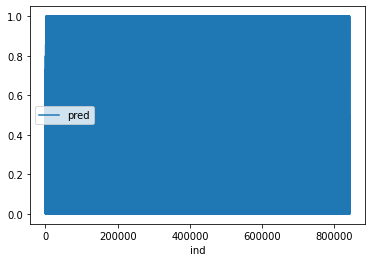

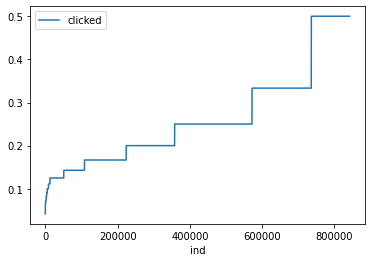

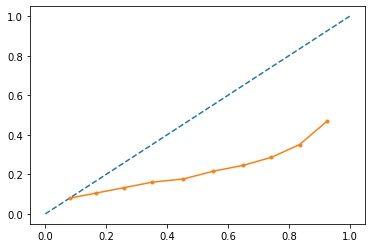

In [ ]:
import joblib
from sklearn.metrics import classification_report,confusion_matrix

filename = project_dir + 'random_forest1.pkl'
random_forest = joblib.load(filename)

pred_prob = random_forest.predict_proba(train)
pred_random_forest_train = random_forest.predict(train)
score(y_train, pred_random_forest_train, pred_prob)
plot(pred_random_forest_train)
reliability_diagram(pred_prob[:, 1])

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import joblib
filename = project_dir + 'random_forest2.pkl'
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)
class_weight='balanced'
random_forest = GridSearchCV(estimator=RandomForestClassifier(n_estimators=20, class_weight='balanced_subsample', max_depth=7),
                             param_grid=param_grid,
                             n_jobs=-1,
                             cv=cv,
                             scoring='roc_auc')

random_forest_result = random_forest.fit(X, y)
joblib.dump(random_forest, filename)

['/content/drive/MyDrive/ML_Project/random_forest2.pkl']

CONFUSION MATRIX
[[0.39981467 0.37670125]
 [0.08574    0.13774408]]
              precision    recall  f1-score   support

           0       0.82      0.51      0.63   2926235
           1       0.27      0.62      0.37    842181

    accuracy                           0.54   3768416
   macro avg       0.55      0.57      0.50   3768416
weighted avg       0.70      0.54      0.58   3768416

AUC:
0.5656156403233353
CROSS-ENTROPY:
0.6814930660431023


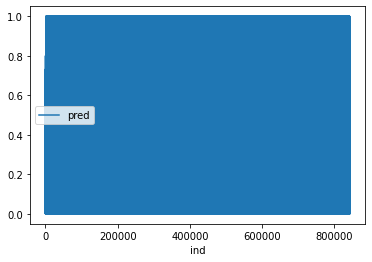

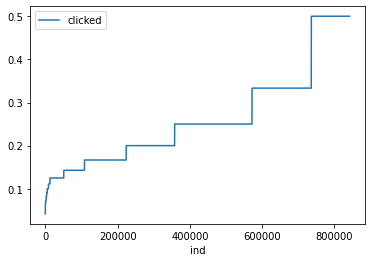

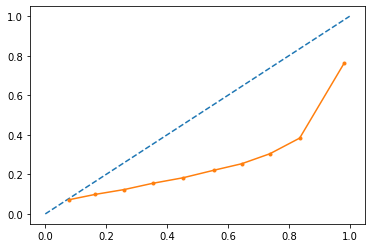

In [ ]:
import joblib
from sklearn.metrics import classification_report,confusion_matrix

filename = project_dir + 'random_forest2.pkl'
random_forest = joblib.load(filename)

pred_prob = random_forest.predict_proba(train)
pred_random_forest_train = random_forest.predict(train)

score(y_train, pred_random_forest_train, pred_prob)
plot( pred_random_forest_train)
reliability_diagram(pred_prob[:, 1])

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import joblib
filename = project_dir + 'random_forest3.pkl'
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=20,
                             n_repeats=1,
                             random_state=1)
class_weight='balanced'
random_forest = GridSearchCV(estimator=RandomForestClassifier(n_estimators=40, class_weight='balanced_subsample', max_depth=10),
                             param_grid=param_grid,
                             n_jobs=-1,
                             cv=cv,
                             scoring='roc_auc')

random_forest_result = random_forest.fit(X, y)
joblib.dump(random_forest, filename)

['/content/drive/MyDrive/ML_Project/random_forest3.pkl']

CONFUSION MATRIX
[[0.41778509 0.35873083]
 [0.08193151 0.14155258]]
              precision    recall  f1-score   support

           0       0.84      0.54      0.65   2926235
           1       0.28      0.63      0.39    842181

    accuracy                           0.56   3768416
   macro avg       0.56      0.59      0.52   3768416
weighted avg       0.71      0.56      0.60   3768416

AUC:
0.5857075567554186
CROSS-ENTROPY:
0.6734032340856937


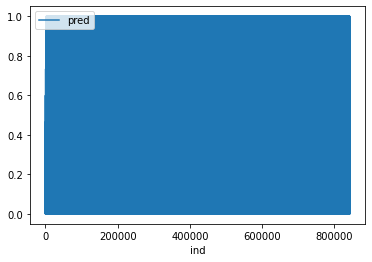

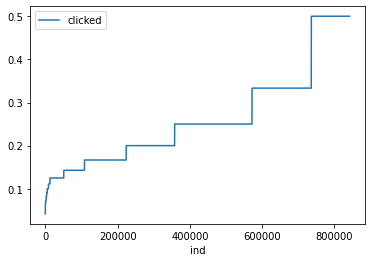

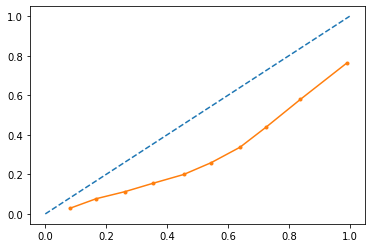

In [ ]:
import joblib
from sklearn.metrics import classification_report,confusion_matrix

filename = project_dir + 'random_forest3.pkl'
random_forest = joblib.load(filename)

pred_prob = random_forest.predict_proba(train)
pred_random_forest_train = random_forest.predict(train)
score(y_train, pred_random_forest_train, pred_prob)
plot(pred_random_forest_train)
reliability_diagram(pred_prob[:, 1])

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import joblib
filename = project_dir + 'random_forest4.pkl'
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=20,
                             n_repeats=1,
                             random_state=1)
class_weight='balanced'
random_forest = GridSearchCV(estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', max_depth=10),
                             param_grid=param_grid,
                             n_jobs=-1,
                             cv=cv,
                             scoring='roc_auc')

random_forest_result = random_forest.fit(X, y)
joblib.dump(random_forest, filename)

['/content/drive/MyDrive/ML_Project/random_forest4.pkl']

CONFUSION MATRIX
[[0.41577708 0.36073884]
 [0.08111153 0.14237255]]
              precision    recall  f1-score   support

           0       0.84      0.54      0.65   2926235
           1       0.28      0.64      0.39    842181

    accuracy                           0.56   3768416
   macro avg       0.56      0.59      0.52   3768416
weighted avg       0.71      0.56      0.59   3768416

AUC:
0.5862491209052973
CROSS-ENTROPY:
0.6732998334312389


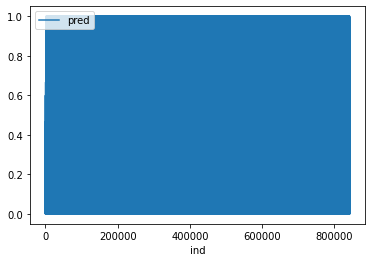

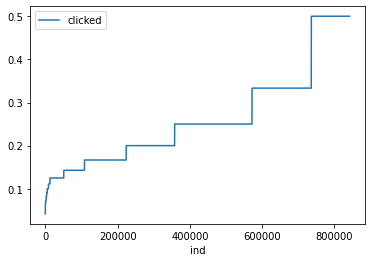

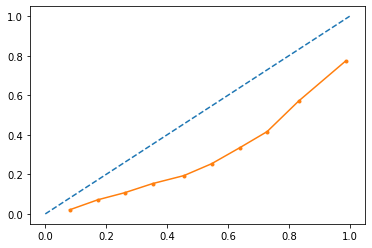

In [ ]:
import joblib
from sklearn.metrics import classification_report,confusion_matrix

filename = project_dir + 'random_forest4.pkl'
random_forest = joblib.load(filename)

pred_prob = random_forest.predict_proba(train)
pred_random_forest_train = random_forest.predict(train)
score(y_train, pred_random_forest_train, pred_prob)
plot(pred_random_forest_train)
reliability_diagram(pred_prob[:, 1])

با توجه به نتایج بدست آمده مدل آحرین بهترین عملکرد را داشته با AUC برابر ۰.۵۸ . چرا که هم تعداد درختانی که استفاده کرده بیشتر بوده‌است و هم کراس ولیدیشن بیشتری داشته است.

In [ ]:
import joblib
filename = project_dir + 'random_forest4.pkl'
random_forest = joblib.load(filename)

pred_random_forest_test = random_forest.predict(test)
prob_random_forest_test = random_forest.predict_proba(test)

joblib.dump(pred_random_forest_test, project_dir+'random_forest_test_pred.pkl')
joblib.dump(prob_random_forest_test, project_dir+'random_forest_test_probs.pkl')

['/content/drive/MyDrive/ML_Project/random_forest_test_probs.pkl']